## **Random Forest - AdaBoost - Gradient Boosting**

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

## **Dataset**

In [24]:
!gdown 1qeJqFtRdjjHqExbWJcgKy0yJbczTTAE3

Downloading...
From: https://drive.google.com/uc?id=1qeJqFtRdjjHqExbWJcgKy0yJbczTTAE3
To: /content/Housing.csv
100% 30.0k/30.0k [00:00<00:00, 73.4MB/s]


In [25]:
dataset_path = './Housing.csv'
df = pd.read_csv(dataset_path)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## **Categorial Encoding**

In [27]:
categorical_cols = df.select_dtypes(include=['object']).columns.to_list()
categorical_cols

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

In [28]:
df['furnishingstatus'].nunique()

3

In [29]:
for col_name in categorical_cols:
    n_categories = df[col_name].nunique()
    print(f'Number of categories in {col_name}: {n_categories}')

Number of categories in mainroad: 2
Number of categories in guestroom: 2
Number of categories in basement: 2
Number of categories in hotwaterheating: 2
Number of categories in airconditioning: 2
Number of categories in prefarea: 2
Number of categories in furnishingstatus: 3


In [30]:
# Import thêm OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

# --- Bước 1: Phân loại các cột categorical ---
# Ghi chú: Chúng ta chia các cột object thành 2 nhóm dựa trên BẢN CHẤT của dữ liệu:
# 1. Nhóm Nominal (danh nghĩa): Các cột không có thứ tự. Bao gồm cả các cột nhị phân ('yes'/'no').
# 2. Nhóm Ordinal (thứ tự): Cột 'furnishingstatus' có giá trị mang tính thứ bậc.

nominal_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

ordinal_cols = [
    'furnishingstatus'
]

# --- Bước 2: Xử lý các cột Nominal bằng OneHotEncoder ---
# Ghi chú: OneHotEncoder là phương pháp chuẩn xác cho dữ liệu nominal.
# Nó tạo ra các cột mới cho mỗi giá trị, tránh việc mô hình hiểu nhầm về thứ tự.
# `sparse_output=False` để kết quả trả về là mảng NumPy.
# `drop='first'` để loại bỏ 1 cột sau khi mã hóa, tránh đa cộng tuyến và giữ cho dữ liệu gọn gàng.
onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')

# Mã hóa các cột nominal
encoded_nominal_cols = onehot_encoder.fit_transform(df[nominal_cols])

# Tạo DataFrame từ kết quả mã hóa, lấy tên cột mới tự động
encoded_nominal_df = pd.DataFrame(
    encoded_nominal_cols,
    columns=onehot_encoder.get_feature_names_out(nominal_cols)
)


# --- Bước 3: Xử lý cột Ordinal bằng OrdinalEncoder ---
# Ghi chú: Đây là trường hợp sử dụng OrdinalEncoder phù hợp nhất.
# Chúng ta chỉ định rõ thứ tự trong 'categories' để đảm bảo việc mã hóa
# phản ánh đúng mối quan hệ (unfurnished < semi-furnished < furnished).
furnishing_order = ['unfurnished', 'semi-furnished', 'furnished']
ordinal_encoder = OrdinalEncoder(categories=[furnishing_order])

# Mã hóa cột ordinal và tạo DataFrame
encoded_ordinal_cols = ordinal_encoder.fit_transform(df[ordinal_cols])
encoded_ordinal_df = pd.DataFrame(
    encoded_ordinal_cols,
    columns=ordinal_cols
)

# --- Bước 4: Kết hợp tất cả dữ liệu lại ---
# Ghi chú: Ta sẽ loại bỏ tất cả các cột object ban đầu và ghép nối
# các cột số ban đầu với các cột đã được mã hóa.

# 1. Lấy ra các cột dạng số ban đầu
numerical_df = df.select_dtypes(exclude=['object'])

# 2. Loại bỏ các cột object ban đầu khỏi DataFrame
# df_for_concat = df.drop(columns=nominal_cols + ordinal_cols)

# 3. Ghép nối các DataFrame: cột số, cột nominal đã mã hóa, cột ordinal đã mã hóa
encoded_df = pd.concat(
    [numerical_df, encoded_nominal_df, encoded_ordinal_df],
    axis=1
)

# In ra 5 dòng đầu của DataFrame đã được mã hóa hoàn chỉnh
encoded_df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus
0,13300000,7420,4,2,3,2,1.0,0.0,0.0,0.0,1.0,1.0,2.0
1,12250000,8960,4,4,4,3,1.0,0.0,0.0,0.0,1.0,0.0,2.0
2,12250000,9960,3,2,2,2,1.0,0.0,1.0,0.0,0.0,1.0,1.0
3,12215000,7500,4,2,2,3,1.0,0.0,1.0,0.0,1.0,1.0,2.0
4,11410000,7420,4,1,2,2,1.0,1.0,1.0,0.0,1.0,0.0,2.0


## **Normalization**

In [31]:
# Ghi chú: Chúng ta sẽ dùng phương thức .fit_transform() trên toàn bộ DataFrame đã mã hóa.
# Thao tác này sẽ thực hiện 2 bước cùng lúc:
# 1. fit(): StandardScaler sẽ HỌC (tính toán) giá trị trung bình (mean) và độ lệch chuẩn (std dev) của TỪNG CỘT trong encoded_df.
# 2. transform(): Dựa trên các giá trị đã học, nó sẽ ÁP DỤNG công thức chuẩn hóa Z-score cho tất cả các giá trị trong DataFrame.
# Kết quả trả về sẽ là một mảng NumPy (không còn là DataFrame).
normalizer = StandardScaler()
dataset_arr = normalizer.fit_transform(encoded_df)

# In ra 5 dòng đầu của mảng đã được chuẩn hóa để kiểm tra
# Lưu ý: Các giá trị bây giờ đều xoay quanh 0.
print(dataset_arr[:5])

[[ 4.56636513  1.04672629  1.40341936  1.42181174  1.37821692  1.51769249
   0.40562287 -0.46531479 -0.73453933 -0.2192645   1.4726183   1.80494113
   1.40628573]
 [ 4.00448405  1.75700953  1.40341936  5.40580863  2.53202371  2.67940935
   0.40562287 -0.46531479 -0.73453933 -0.2192645   1.4726183  -0.55403469
   1.40628573]
 [ 4.00448405  2.21823241  0.04727831  1.42181174  0.22441013  1.51769249
   0.40562287 -0.46531479  1.3613975  -0.2192645  -0.67906259  1.80494113
   0.09166185]
 [ 3.98575468  1.08362412  1.40341936  1.42181174  0.22441013  2.67940935
   0.40562287 -0.46531479  1.3613975  -0.2192645   1.4726183   1.80494113
   1.40628573]
 [ 3.55497918  1.04672629  1.40341936 -0.57018671  0.22441013  1.51769249
   0.40562287  2.14908276  1.3613975  -0.2192645   1.4726183  -0.55403469
   1.40628573]]


## **Train test split and Normalization**

> Add blockquote



In [32]:
# 1. Tách features (X) và target (y) từ encoded_df
X = encoded_df.drop('price', axis=1)
y = encoded_df['price']

In [33]:
# 2. Chia dữ liệu
# Ghi chú: Thêm `shuffle=True` để thể hiện rõ ý định xáo trộn dữ liệu trước khi chia.
# Dù đây là hành vi mặc định, việc ghi rõ ra giúp code dễ đọc và dễ hiểu hơn.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1,
    shuffle=True
)

# 3. Khởi tạo và fit scaler CHỈ trên tập train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. Áp dụng scaler đã fit lên tập test
X_test_scaled = scaler.transform(X_test)

print("Đã hoàn tất việc chia và chuẩn hóa dữ liệu.")
print("Shape của X_train_scaled:", X_train_scaled.shape)
print("Shape của X_test_scaled:", X_test_scaled.shape)

Đã hoàn tất việc chia và chuẩn hóa dữ liệu.
Shape của X_train_scaled: (381, 12)
Shape của X_test_scaled: (164, 12)


## **Training & Evaluation**

### **Random Forest**

In [34]:
# Ghi chú: Chúng ta sẽ khởi tạo mô hình RandomForestRegressor với các tham số cơ bản.
# - n_estimators: Số lượng cây trong rừng. Đây là một trong những tham số quan trọng nhất.
# - max_depth: Độ sâu tối đa của mỗi cây. Giúp kiểm soát độ phức tạp của mô hình, tránh overfitting.
# - random_state: Đảm bảo kết quả huấn luyện (ví dụ: cách chọn feature, cách bootstrap mẫu)
#   là nhất quán và có thể tái tạo lại trong mỗi lần chạy.
regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=1
)

# Huấn luyện mô hình trên dữ liệu train đã được chuẩn hóa
print("Đang huấn luyện mô hình RandomForest...")
regressor.fit(X_train_scaled, y_train)
print("Huấn luyện hoàn tất!")


# --- Đánh giá mô hình ---
# Ghi chú: Sử dụng mô hình đã huấn luyện để dự đoán trên tập test (cũng đã được chuẩn hóa).
# Sau đó, so sánh kết quả dự đoán (y_pred) với giá trị thực tế (y_test)
# để đo lường độ chính xác của mô hình.
print("\nĐang đánh giá mô hình trên tập test...")
y_pred = regressor.predict(X_test_scaled)

# Tính toán các chỉ số lỗi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Căn bậc hai của MSE

print(f"Mean Absolute Error (MAE): {mae:,.0f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.0f}")

Đang huấn luyện mô hình RandomForest...
Huấn luyện hoàn tất!

Đang đánh giá mô hình trên tập test...
Mean Absolute Error (MAE): 851,820
Root Mean Squared Error (RMSE): 1,148,843


Biểu đồ đã được lưu vào file 'prediction_vs_actual_scatter.png'


/tmp/ipython-input-20177590.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test['area'], y_pred, alpha=0.7, label='Giá dự đoán', edgecolor="black", c="red", marker='x')


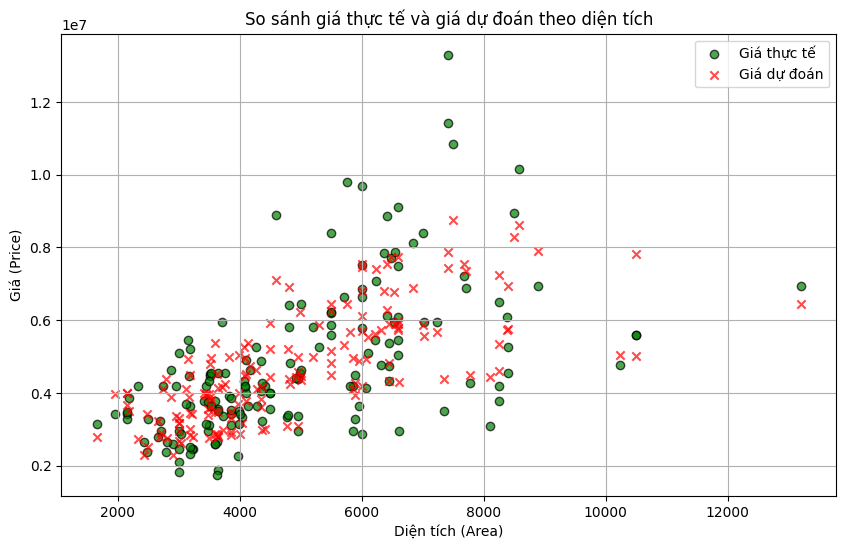

In [35]:
# --- Trực quan hóa kết quả dự đoán ---
# Ghi chú: Để trực quan hóa, chúng ta cần dữ liệu gốc của các feature trong tập test.
# DataFrame `X_test` chứa thông tin này (ví dụ: cột 'area').
# `y_test` là giá thực tế và `y_pred` là giá mô hình đã dự đoán.

plt.figure(figsize=(10, 6))

# Vẽ các điểm dữ liệu thực tế (Actual)
plt.scatter(X_test['area'], y_test, alpha=0.7, label='Giá thực tế', edgecolor="black", c="green")

# Vẽ các điểm dữ liệu dự đoán (Predicted)
plt.scatter(X_test['area'], y_pred, alpha=0.7, label='Giá dự đoán', edgecolor="black", c="red", marker='x')

# Thiết lập các thông tin cho biểu đồ
plt.title('So sánh giá thực tế và giá dự đoán theo diện tích')
plt.xlabel('Diện tích (Area)')
plt.ylabel('Giá (Price)')
plt.legend()
plt.grid(True)

# Lưu biểu đồ ra file ảnh
plt.savefig('prediction_vs_actual_scatter.png')

print("Biểu đồ đã được lưu vào file 'prediction_vs_actual_scatter.png'")

### **AdaBoost**

In [36]:
# Ghi chú: Chúng ta sẽ khởi tạo mô hình AdaBoostRegressor.
# - n_estimators: Số lượng mô hình yếu (weak learners) được huấn luyện tuần tự.
# - learning_rate: Trọng số áp dụng cho mỗi mô hình trong chuỗi.
#   Giá trị nhỏ hơn 1.0 thường làm cho mô hình học chậm hơn nhưng ổn định hơn.
# - loss: Hàm lỗi được sử dụng để cập nhật trọng số của các mẫu dữ liệu. 'linear' là mặc định.
# - random_state: Đảm bảo tính nhất quán cho việc khởi tạo trọng số.
regressor_ada = AdaBoostRegressor(
    n_estimators=50,
    learning_rate=0.1,
    loss='linear',
    random_state=1
)

# Huấn luyện mô hình trên dữ liệu train đã được chuẩn hóa
print("Đang huấn luyện mô hình AdaBoost...")
regressor_ada.fit(X_train_scaled, y_train)
print("Huấn luyện hoàn tất!")


# --- (AdaBoost): Đánh giá mô hình ---
# Ghi chú: Sử dụng mô hình AdaBoost đã huấn luyện để dự đoán trên tập test.
print("\nĐang đánh giá mô hình trên tập test...")
y_pred_ada = regressor_ada.predict(X_test_scaled)

# Tính toán các chỉ số lỗi
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mse_ada = mean_squared_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mse_ada)

print(f"Mean Absolute Error (MAE): {mae_ada:,.0f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ada:,.0f}")

Đang huấn luyện mô hình AdaBoost...
Huấn luyện hoàn tất!

Đang đánh giá mô hình trên tập test...
Mean Absolute Error (MAE): 984,598
Root Mean Squared Error (RMSE): 1,348,856


Biểu đồ đã được lưu vào file 'adaboost_prediction_scatter.png'


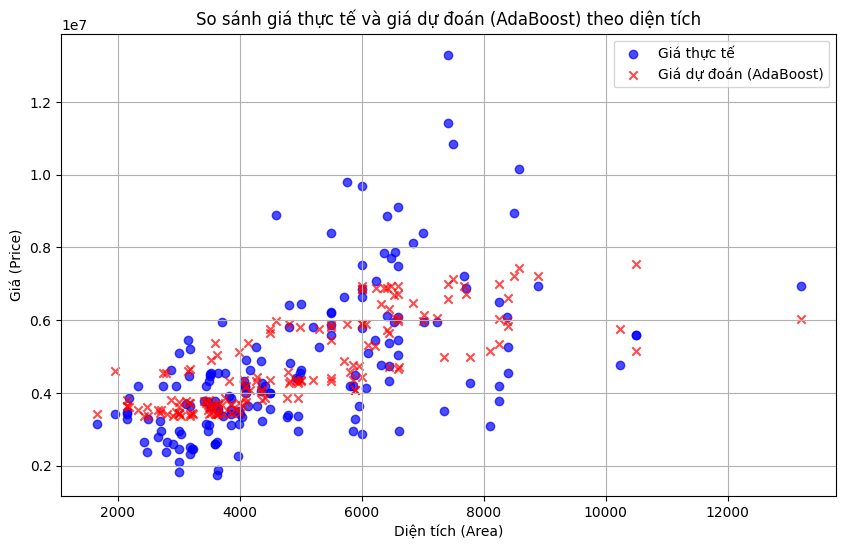

In [37]:
# --- (AdaBoost): Trực quan hóa kết quả dự đoán ---
# Ghi chú: Tương tự như với RandomForest, chúng ta sẽ vẽ giá trị thực tế
# và giá trị dự đoán của AdaBoost trên cùng một biểu đồ.

plt.figure(figsize=(10, 6))

# Vẽ các điểm dữ liệu thực tế (Actual)
plt.scatter(X_test['area'], y_test, alpha=0.7, label='Giá thực tế', color='blue')

# Vẽ các điểm dữ liệu dự đoán của AdaBoost (Predicted)
# Chúng ta dùng marker và màu sắc khác để dễ phân biệt
plt.scatter(X_test['area'], y_pred_ada, alpha=0.7, label='Giá dự đoán (AdaBoost)', color='red', marker='x')

# Thiết lập các thông tin cho biểu đồ
plt.title('So sánh giá thực tế và giá dự đoán (AdaBoost) theo diện tích')
plt.xlabel('Diện tích (Area)')
plt.ylabel('Giá (Price)')
plt.legend()
plt.grid(True)

# Lưu biểu đồ ra file ảnh mới
plt.savefig('adaboost_prediction_scatter.png')

print("Biểu đồ đã được lưu vào file 'adaboost_prediction_scatter.png'")

### **Gradient Boosting**

In [38]:
# --- (Gradient Boosting): Khởi tạo và Huấn luyện mô hình ---
# Ghi chú: Chúng ta sẽ khởi tạo mô hình GradientBoostingRegressor.
# - n_estimators: Số lượng cây (boosting stages) sẽ được thực hiện.
# - learning_rate: Giảm sự đóng góp của mỗi cây, giúp chống lại overfitting.
# - max_depth: Độ sâu tối đa của mỗi cây quyết định.
# - random_state: Đảm bảo tính nhất quán và khả năng tái tạo kết quả.
regressor_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=1
)

# Huấn luyện mô hình trên dữ liệu train đã được chuẩn hóa
print("Đang huấn luyện mô hình Gradient Boosting...")
regressor_gb.fit(X_train_scaled, y_train)
print("Huấn luyện hoàn tất!")


# --- Bước 6 (Gradient Boosting): Đánh giá mô hình ---
print("\nĐang đánh giá mô hình trên tập test...")
y_pred_gb = regressor_gb.predict(X_test_scaled)

# Tính toán các chỉ số lỗi
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)

print(f"Mean Absolute Error (MAE): {mae_gb:,.0f}")
print(f"Root Mean Squared Error (RMSE): {mse_gb:,.0f}")

Đang huấn luyện mô hình Gradient Boosting...
Huấn luyện hoàn tất!

Đang đánh giá mô hình trên tập test...
Mean Absolute Error (MAE): 843,157
Root Mean Squared Error (RMSE): 1,384,481,567,768



Đang tạo biểu đồ trực quan hóa...
Biểu đồ đã được lưu vào file 'gradientboosting_prediction_scatter.png'


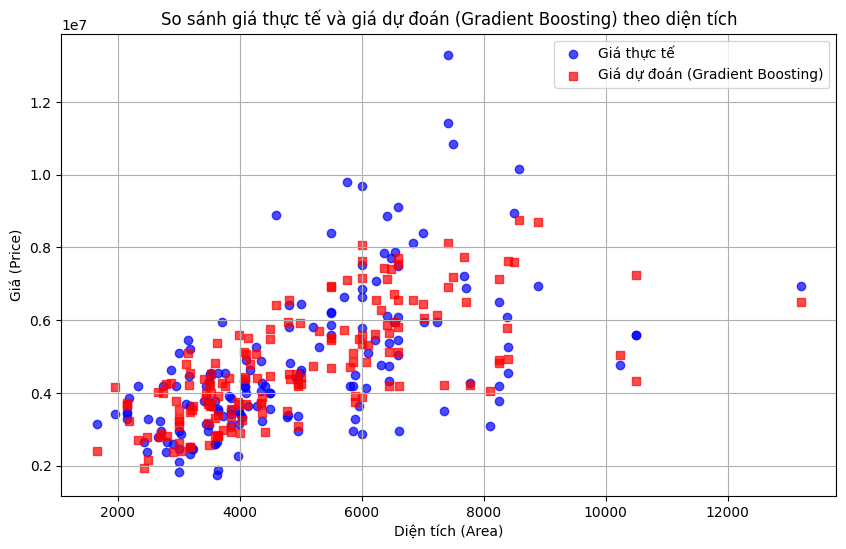

In [39]:
print("\nĐang tạo biểu đồ trực quan hóa...")
plt.figure(figsize=(10, 6))

# Vẽ các điểm dữ liệu thực tế (Actual)
plt.scatter(X_test['area'], y_test, alpha=0.7, label='Giá thực tế', color='blue')

# Vẽ các điểm dữ liệu dự đoán của Gradient Boosting (Predicted)
plt.scatter(X_test['area'], y_pred_gb, alpha=0.7, label='Giá dự đoán (Gradient Boosting)', color='red', marker='s')

# Thiết lập các thông tin cho biểu đồ
plt.title('So sánh giá thực tế và giá dự đoán (Gradient Boosting) theo diện tích')
plt.xlabel('Diện tích (Area)')
plt.ylabel('Giá (Price)')
plt.legend()
plt.grid(True)

# Lưu biểu đồ ra file ảnh mới
plt.savefig('gradientboosting_prediction_scatter.png')

print("Biểu đồ đã được lưu vào file 'gradientboosting_prediction_scatter.png'")